In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import gudhi.point_cloud.timedelay as td
from tqdm.auto import tqdm
import seaborn as sns
import gudhi.representations as gr

import pandas as pd
from copy import deepcopy
import scipy
import scipy.integrate

import tsi_functions as tsi
import tsi_functions.time_series as tsi_ts

In [ ]:
def SampleOnCircle(N_obs=100, N_out=0, is_plot=False, noise_type="uniform", sigma=1):
    """
    Sample N_obs points (observations) points from the uniform distribution on the unit circle in R^2,
        and N_out points (outliers) from the uniform distribution on the unit square

    Input:
    N_obs: number of sample points on the circle
    N_noise: number of sample points on the square
    is_plot = True or False : draw a plot of the sampled points

    Output :
    data : a (N_obs + N_out)x2 matrix, the sampled points concatenated
    """
    rand_uniform = np.random.rand(N_obs) * 2 - 1
    X_obs = np.cos(2 * np.pi * rand_uniform)
    Y_obs = np.sin(2 * np.pi * rand_uniform)

    if noise_type == "uniform":
        X_out = np.random.rand(N_out) * 2 - 1
        Y_out = np.random.rand(N_out) * 2 - 1

        X = np.concatenate((X_obs, X_out))
        Y = np.concatenate((Y_obs, Y_out))
        data = np.stack((X, Y)).transpose()
    
    elif noise_type == "gaussian":
        X_out = X_obs + np.random.normal(0, sigma, size=X_obs.shape)
        Y_out = Y_obs + np.random.normal(0, sigma, size=Y_obs.shape)

        data = np.stack((X_out, Y_out)).transpose()
    if is_plot:
        fig, ax = plt.subplots()
        plt_obs = ax.scatter(X_obs, Y_obs, c="tab:cyan")
        # plt_out = ax.scatter(X_out, Y_out, c="tab:orange")
        ax.axis("equal")
        ax.set_title(str(N_obs) + "-sampling of the unit circle with " + str(N_out) + " outliers")
        # ax.legend((plt_obs, plt_out), ("data", "outliers"), loc="lower left")

0.0


/home/siroj/miniconda3/envs/brownian_motion/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")
/tmp/ipykernel_11433/3683154710.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


Text(0.5, 1.0, '$cv$TSI = 0.0, $H_2$ = 1.61')

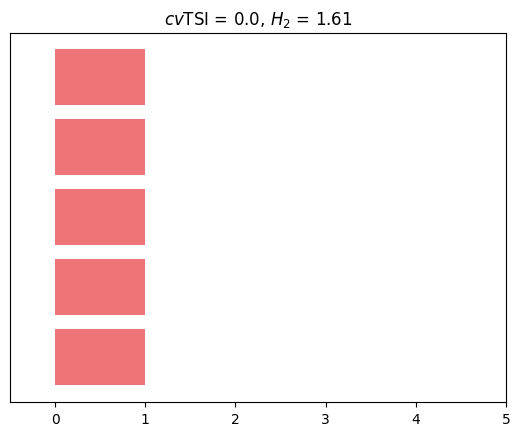

In [ ]:
np.random.seed(123)

# data = SampleOnCircle(N_obs=6, N_out=0, is_plot=True, noise_type="gaussian", sigma=.07)
# n = 5
# data = PointsOnCircle(n, radius = 4*1/(n-1)*(np.sin((n-2)/(2*n)*np.pi))/np.sin(2*np.pi/n))
# persistence = tsi.filtration_from_points(data, filtration_type="rips", max_dim=3, max_edge_length=2)

# persistence = [(0, (0, 1)), (0, (0,2))]
persistence = [(0, (0, 1)) for _ in range(5)]
# persistence[0] = (0, (0, 4))

# persistence = [(q, (bar[0], bar[1])) for (q, bar) in persistence if bar[1] < np.inf and q == 0]
# persistence = [(q, (bar[0]*2, bar[1]*2)) for (q, bar) in persistence]
# persistence = [(q, (bar[0], bar[1]+1)) for (q, bar) in persistence]

mean_pers = np.mean([bar[1] - bar[0] for (q, bar) in persistence])
# persistence.append((0,(0,mean_pers)))
# persistence.append((0,(0,0.5)))

print(tsi.top_summary_functions(persistence)["TSI-0"])
gd.plot_persistence_barcode([(q, bar) for (q, bar) in persistence if bar[1] < np.inf and q == 0], max_intervals = 10, inf_delta = 5)
# Remove legend
plt.legend().remove()
plt.xlim(-0.5,5)
# plt.axvline(mean_pers, color="tab:red", linestyle="--", linewidth=2, label="Mean persistence")
# plt.legend(loc="lower right")


# plt.title("TSI = " + str(round(tsi.top_summary_functions(persistence)["TSI-0"], 2)))
plt.title("$cv$TSI = " + str(round(tsi.top_summary_functions(persistence)["cvTSI-0"], 2)) + ", $H_2$ = " + str(round(tsi.top_summary_functions(persistence)["Renyi_2-0"], 2)))
# plt.savefig("cvTSI_Renyi_2_uniform.png", dpi=300, bbox_inches='tight')
# plt.xticks([0,1,4,6], labels=["0",r"$\\dfrac{L}{n}$","$L$",r"$\\infty$"])

Text(0, 0.5, 'Change in TSI')

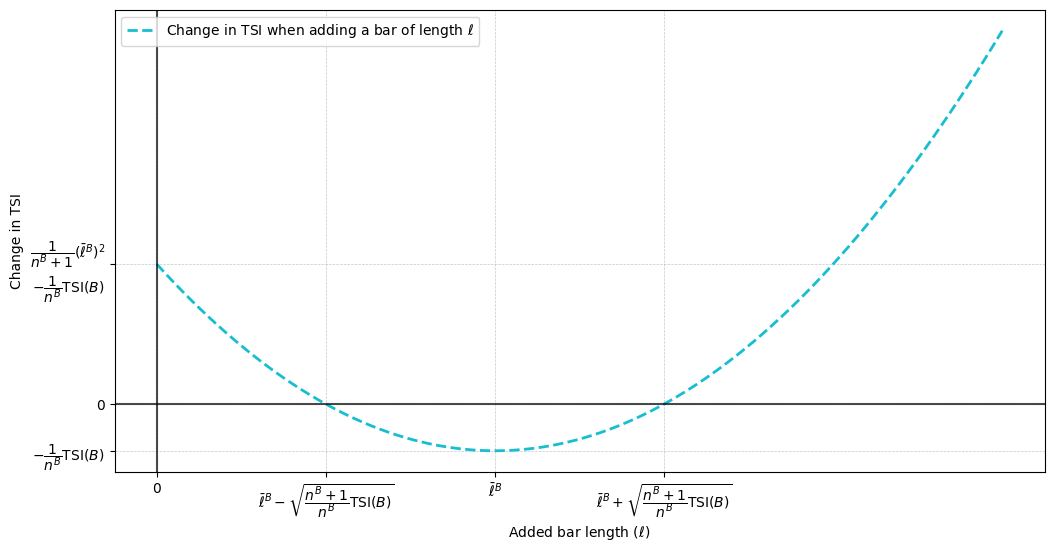

In [3]:
x_axis = np.linspace(0, 5, 100)
plt.figure(figsize=(12, 6))
y_axis = (x_axis-2)**2-1
plt.plot(x_axis, y_axis, color="tab:cyan", linestyle="--", linewidth=2, label=r"Change in TSI when adding a bar of length $\ell$")
plt.legend(loc="upper left")
plt.grid(visible=True, which='major', linewidth=0.5, linestyle='--', alpha=0.7)
plt.axvline(0, color="black", linestyle="-", linewidth=1.5, alpha=0.7)
plt.axhline(0, color="black", linestyle="-", linewidth=1.5, alpha=0.7)
# plt.xticks([0,1,2,3], labels=["0","$\\bar{\\ell}^B-t$","$\\bar{\\ell}^B$","$\\bar{\\ell}^B+t$"])
plt.xticks([0,1,2,3], labels=["0","$\\bar{\\ell}^B-\\sqrt{\\dfrac{n^B+1}{n^B}\\text{TSI}(B)}$","$\\bar{\\ell}^B$","$\\bar{\\ell}^B+\\sqrt{\\dfrac{n^B+1}{n^B}\\text{TSI}(B)}$"])
plt.yticks([-1, 0,3], labels=["$-\\dfrac{1}{n^B}\\text{TSI}(B)$", "0","$\\dfrac{1}{n^B+1}(\\bar{\\ell}^B)^2$\n$-\\dfrac{1}{n^B}\\text{TSI}(B)$"])
plt.xlabel("Added bar length ($\ell$)")
plt.ylabel("Change in TSI")
# plt.savefig("TSI_change.png", dpi=300, bbox_inches='tight')

In [ ]:
def PointsOnCircle(N, radius=1):
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    return np.column_stack((x, y))

def PointsOnTwoCircles(N, radii = [1, 1], centres = [(-1.5, 0), (1.5, 0)]):
    data_1 = PointsOnCircle(int((N* radii[0])/sum(radii)), radius=radii[0]) + np.array(centres[0])
    data_2 = PointsOnCircle(int((N* radii[1])/sum(radii)), radius=radii[1]) + np.array(centres[1])
    data = np.concatenate([data_1, data_2])
    return data

def PointsOnThreeCircles(N, radii = [1, 1, 1], centres = [(-1, 0), (1, 0), (0, 1)]):
    data_1 = PointsOnCircle(int((N* radii[0])/sum(radii)), radius=radii[0]) + np.array(centres[0])
    data_2 = PointsOnCircle(int((N* radii[1])/sum(radii)), radius=radii[1]) + np.array(centres[1])
    data_3 = PointsOnCircle(int((N* radii[2])/sum(radii)), radius=radii[2]) + np.array(centres[2])
    data = np.concatenate([data_1, data_2, data_3])
    return data

max_edge_length = 20
n = 20
# data = PointsOnTwoCircles(n, radii=[1, 0.25], centres=[(-7.5, 0), (7.5, 0)])
# data = PointsOnCircle(n, radius = 4*1/(n-1)*(np.sin((n-2)/(2*n)*np.pi))/np.sin(2*np.pi/n))
data = PointsOnCircle(n, radius = 1/(2*np.cos(np.pi/6)))
# data = PointsOnCircle(n, radius = 4*1/(n-1)*(np.sin((n-2)/(2*n)*np.pi))/np.sin(2*np.pi/n))
# data[0] = np.array([3.8,0])



# data = np.array([[0,0],[0,1e-15],[0,2e-15],[0,3e-15],[4,0]])
# data += np.random.normal(0, 0.05, size=data.shape)
plt.scatter(data[:, 0], data[:, 1], alpha=0.7)
plt.axis("equal")
# plt.savefig("/mnt/c/PhD/TSI/figures/single_bar_points.png", dpi=300, bbox_inches='tight')
plt.show()
persistence = tsi.filtration_from_points(data, filtration_type="rips", max_dim=2, max_edge_length=max_edge_length, dtm=False)
print("exact birth", 2*np.sin(np.pi/(4*(n)//5)), 2*0.25*np.sin(np.pi/((n)//5)))
print("approximate birth", 2*(np.pi/(4*(n)//5)), 2*0.25*(np.pi/((n)//5)))
print("dist 0,1:", np.linalg.norm(data[0]-data[1]), "dist 0,2:", np.linalg.norm(data[0]-data[2]), "dist 0,3:", np.linalg.norm(data[0]-data[3]), "dist 0,n//4-1:", np.linalg.norm(data[0]-data[n//4+1]))
print( [persistence[i] for i in range(len(persistence)) if persistence[i][0] == 1])
print("TSI:", tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)["TSI-1"])
print("Entropy:", tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)["persistent_entropy-1"])
# print([bar for dim, bar in persistence if dim == 1])
# plt.hist([bar[1]-bar[0] for dim, bar in persistence if dim == 1], bins=100)
gd.plot_persistence_diagram(persistence)

In [ ]:
gd.plot_persistence_barcode([(q, bar) for (q, bar) in persistence if bar[1] < np.inf and q == 0], max_intervals = 10, inf_delta = 5)
# gd.plot_persistence_barcode([(q, bar) for (q, bar) in persistence if q == 0], max_intervals = 10, inf_delta = 5)
plt.xlim(-0.5,6)
# plt.title("TSI = "+str(np.round(tsi.top_summary_functions([(q, bar) for (q, bar) in persistence if bar[1] < np.inf and q == 0], theoretical_max_r=max_edge_length)["TSI-0"], 2)))

plt.xticks([0,1,4,6], labels=["0",r"$\dfrac{L}{n}$","$L$",r"$\infty$"])
# plt.xticks([0,1,2,3,4,5,6], labels=["0","1","2","3","4","5",r"$\infty$"])

# plt.savefig("/mnt/c/PhD/TSI/figures/equidistant_barcode.png", dpi=300, bbox_inches='tight')